### Configuration


In [ ]:
target = 'pxr'  # 'ahr', 'pxr', 'car' The file names must be {target}_ligands.csv
model_name = 'xgb'  # 'rf', 'xgb', 'svm', 'lr', 'stacking'

In [ ]:
import os
from pathlib import Path
import sys

# Define xenotox as base directory
BASE_DIR = Path(f"{os.getcwd()}/..").resolve()

# Add parent directory to sys.path for imports
sys.path.append(str(BASE_DIR))

# Create output directories
os.makedirs(f"{BASE_DIR}/outputs_clf/{target}/models", exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs_clf/{target}/plots", exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs_clf/{target}/reports", exist_ok=True)

### Curation

In [3]:
import pandas as pd
from utils_clf.curation import curate_data

# Load data
df = pd.read_csv(f"{BASE_DIR}/ligands/{target}/{target}_ligands.csv")

# Curate data
df_curated = curate_data(df,"SMILES", "Agonist_Activity")
display(df_curated.head())

Curation completed: 6258 valid molecules (out of 6260 initial).


,Agonist_Activity,SMILES
0,inactive,BrC(Br)Br
1,inactive,BrC(Br)C(Br)(Br)Br
2,inactive,BrC(Br)C(Br)Br
3,inactive,BrC/C=C/CBr
4,active,BrC1CCC(Br)C(Br)CCC(Br)C(Br)CCC1Br


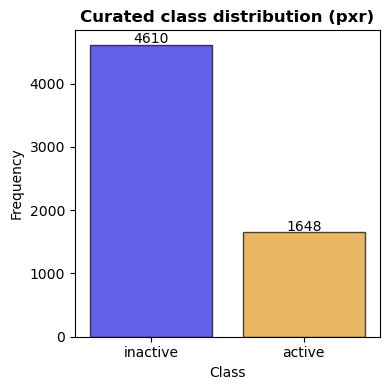

In [4]:
from utils_clf.class_distribution import plot_dist

# Plot curated class distribution
plot = plot_dist(df_curated, "Agonist_Activity", target)

# Save figure
plot.savefig(f"{BASE_DIR}/outputs_clf/{target}/plots/{target}_class_dist.png", dpi=300)

### Descriptors


In [5]:
from utils_clf.descriptors import descriptor_matrix

# Generate X and y
X, y = descriptor_matrix(df_curated, "SMILES", "Agonist_Activity")

# Full descriptor list for saving model components
full_descriptor_list = X.columns.tolist()

print(f"Descriptor matrix shape: {X.shape}")

Initializing calculation with 10 cores...


RDKit progress: 100%|██████████| 6258/6258 [00:07<00:00, 797.84it/s] 


Descriptor matrix shape: (6230, 217)


### Data split and encoding

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.3,
    random_state=42
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 4361 | Test: 1869


In [7]:
y_train_enc = y_train.map({"inactive": 0, "active": 1})
y_test_enc = y_test.map({"inactive": 0, "active": 1})

count_train = pd.Series(y_train_enc).value_counts()
count_test = pd.Series(y_test_enc).value_counts()

print(f"Train distribution: Active(1) = {count_train[1]}, Inactive(0) = {count_train[0]}")
print(f"Test distribution: Active(1) = {count_test[1]}, Inactive(0) = {count_test[0]}")

Train distribution: Active(1) = 1144, Inactive(0) = 3217
Test distribution: Active(1) = 490, Inactive(0) = 1379


### Feature filtering


In [8]:
from utils_clf.filtering import filter_features

X_train_filtered, X_test_filtered = filter_features(X_train, X_test)

Variance Filter (threshold 0.01)
Deleted features by variance: 24
Features after variance: 193

Correlation Filter (threshold 0.9)
Deleted features by correlation: 43
Final features post-filtering: 150


### Genetic Algorithm

In [9]:
from utils_clf.ga import ga_feature_selection

# Extract filtered feature names for ga
filtered_features = X_train_filtered.columns.tolist()

# Run GA
selected_features = ga_feature_selection(X_train_filtered, y_train_enc, filtered_features)

/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 

gen	nevals	avg	max	min
0  	50    	nan	nan	nan


/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 

1  	41    	nan	nan	nan


/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 

...

/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 

29 	47    	nan	nan	nan


/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 

30 	39    	nan	nan	nan

 Selected features: 50
 Descriptors:
 1. MaxAbsEStateIndex
 2. MinEStateIndex
 3. qed
 4. MolWt
 5. MinPartialCharge
 6. BCUT2D_MWHI
 7. BCUT2D_MWLOW
 8. BCUT2D_LOGPLOW
 9. BCUT2D_MRLOW
10. AvgIpc
11. PEOE_VSA10
12. PEOE_VSA12
13. PEOE_VSA2
14. PEOE_VSA3
15. PEOE_VSA9
16. SMR_VSA1
17. SMR_VSA10
18. SMR_VSA2
19. SMR_VSA3
20. SMR_VSA7
21. SMR_VSA9
22. SlogP_VSA12
23. SlogP_VSA3
24. TPSA
25. EState_VSA11
26. EState_VSA3
27. EState_VSA9
28. VSA_EState2
29. VSA_EState6
30. VSA_EState7
31. NumAliphaticCarbocycles
32. NumAliphaticRings
33. NumAromaticRings
34. NumHeteroatoms
35. fr_Al_COO
36. fr_ArN
37. fr_Ar_OH
38. fr_COO
39. fr_C_S
40. fr_Imine
41. fr_NH0
42. fr_Ndealkylation1
43. fr_alkyl_halide
44. fr_allylic_oxid
45. fr_furan
46. fr_halogen
47. fr_nitro
48. fr_piperzine
49. fr_quatN
50. fr_urea


/Users/madariaga/miniconda3/envs/qsar_classif_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
# Save selected features as dataframe
selected_features_df = pd.DataFrame(selected_features, columns=["Selected_Features"])
selected_features_df.to_csv(f"{BASE_DIR}/outputs_clf/{target}/reports/selected_features.csv", index=False)

### Preprocessing

In [ ]:
from utils_clf.preprocessor import build_preprocessor
preprocessor = build_preprocessor()

# Process filtered and selected features for training and testing
X_train_proc = preprocessor.fit_transform(X_train_filtered[selected_features])
X_test_proc = preprocessor.transform(X_test_filtered[selected_features])


### Training with optimization

In [ ]:
from utils_clf.optimization import optimize_model, save_model
from utils_clf.optimization import train_stacking_model

if model_name == "stacking":
    final_model = train_stacking_model(X_train_proc, y_train_enc)
    save_model(BASE_DIR, target, model_name, final_model,
            full_descriptor_list, selected_features, preprocessor)
    
else:
    final_model = optimize_model(X_train_proc, y_train_enc, model_name)
    save_model(BASE_DIR, target, model_name, final_model, 
            full_descriptor_list, selected_features, preprocessor)

### Internal validation

In [ ]:
from utils_clf.validation import compute_metrics
plot, metrics = compute_metrics(final_model, X_test_proc, y_test_enc, model_name, target)
plot.show()

#Save metrics and plot
metrics['metrics_df'].to_csv(f"{BASE_DIR}/outputs_clf/{target}/reports/internal_validation_{target}_{model_name}.csv", index=False)
plot.savefig(f"{BASE_DIR}/outputs_clf/{target}/plots/internal_roc_pr_{target}_{model_name}.png", dpi=300)

### Applicability Domain (AD)


In [ ]:
from utils_clf.applicability_domain import applicability_domain_analysis as ad
y_proba = metrics["y_proba"]
plot = ad(target, model_name, X_train_proc, X_test_proc, y_test_enc, y_proba)
plot.show()
# Save plot
plot.savefig(f"{BASE_DIR}/outputs_clf/{target}/plots/ad_{target}_{model_name}.png", dpi=300, bbox_inches="tight")

### External Validation

In [ ]:
# Load external dataset
df_ext = pd.read_csv(f"{BASE_DIR}/ext_ligands/{target}/ext_{target}_ligands.csv")
# Curation
df_ext_curated = curate_data(df_ext,"SMILES", "Agonist_Activity")
# Descriptor calculation
X_ext, y_ext = descriptor_matrix(df_ext_curated, "SMILES", "Agonist_Activity")
# Split and encode labels
X_ext_train, X_ext_test, y_ext_train, y_ext_test = train_test_split(
    X_ext, y_ext,
    stratify=y_ext,
    test_size=0.3,
    random_state=42
)
y_ext_train_enc = y_ext_train.map({"inactive": 0, "active": 1})
# Apply selected features to train set
X_ext_filtered = X_ext_train[selected_features]
# Preprocess
X_ext_proc = preprocessor.transform(X_ext_filtered)
# Evaluation
plot_ext, metrics_ext = compute_metrics(final_model, X_ext_proc, y_ext_train_enc, model_name, target, data_type="external")

# Save metrics and plot
metrics_ext['metrics_df'].to_csv(
    f"{BASE_DIR}/outputs_clf/{target}/reports/external_validation_{target}_{model_name}.csv", index=False)
plot_ext.savefig(
    f"{BASE_DIR}/outputs_clf/{target}/plots/external_roc_pr_{target}_{model_name}.png", dpi=300)

In [ ]:
# Applicability domain analysis for external set
y_ext_proba = metrics_ext["y_proba"]
ext_ad = ad(target, model_name, X_train_proc, X_ext_proc, y_ext_train_enc, y_ext_proba)
ext_ad.show()

# Save plot
ext_ad.savefig(f"{BASE_DIR}/outputs_clf/{target}/plots/ad_ext_{target}_{model_name}.png", dpi=300, bbox_inches="tight")